<a href="https://colab.research.google.com/github/santed7/Data-Science-Cohort-20/blob/main/Project-1/Final_Project_One_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – Transaction Prediction with Gaussian Naive Bayes

This notebook presents a clean final submission for Project 1. It follows a clear machine learning workflow:
1. Load and inspect the data
2. Define the problem and target variable
3. Clean and prepare the dataset
4. Build and evaluate a Gaussian Naive Bayes model
5. Compare results using a balanced 50/50 dataset

##**Problem Definition**
The objective of this project is to develop a machine learning model that predicts whether a customer transaction will occur.

- The dataset contains historical transaction records with many predictor variables and a target variable labeled target.

- The target variable represents the outcome of the transaction:

- 1 = successful transaction

- 0 = no transaction

- Because the target variable has two possible outcomes, this is a binary classification problem.

- The model used in this project is Gaussian Naive Bayes, which estimates the probability that a transaction will occur based on the predictor variables in the dataset.

- The workflow for this project includes data inspection, data cleaning, model training, model evaluation, and comparison using a balanced dataset.


Problem Definition [Short version]

### Business Problem
If patterns in historical transaction data suggest that a customer is likely to complete a purchase, then the model predicts a higher probability of a successful transaction.

### Data Science Problem
This is a supervised machine learning problem because the dataset contains labeled outcomes.

### Target Variable
The target variable is `target`.

- `1` = successful transaction
- `0` = no transaction

### Statistical Type of Target
The target variable is categorical with two possible values.

### Machine Learning Problem Type
This is a binary classification problem.

#AI Assistance Statement

This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of machine learning steps such as data cleaning, model training, and cross-validation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the modeling process and interpreting the results.

##Data Collection/Sources

### 1. Import Libraries

These libraries are used for:
- data loading and cleaning
- plotting
- model training and evaluation

In [ ]:
# --------------------------------------------------
# Load Required Libraries
# These libraries are used for data manipulation,
# visualization, and machine learning.
# --------------------------------------------------

import pandas as pd
# Pandas is the main library for working with tabular data.
# Used here to load the CSV file into a DataFrame,
# inspect the dataset, clean missing values, and prepare features.

import numpy as np
# NumPy is used for numerical computing.
# It helps with arrays, math operations, and calculations.
# Used here to store the 100 CV accuracy scores in np.zeros before the loop.

import matplotlib.pyplot as plt
# Matplotlib is a basic plotting library for Python.
# Used here for building charts such as histograms and bar charts.
# Most other visualization libraries (like Seaborn) are built on top of Matplotlib.

import seaborn as sns
# Seaborn is a higher-level visualization library built on Matplotlib.
# It makes it easier to create attractive statistical graphics
# such as heatmaps, boxplots, and countplots.
# Used here for the correlation heatmap to check GNB's independence assumption.

from sklearn import metrics, model_selection
# These are utility modules from scikit-learn:
# - metrics:         tools for evaluating model performance (e.g. confusion matrix)
# - model_selection: tools for splitting data and validation

from sklearn.model_selection import train_test_split, cross_val_score
# Two tools from scikit-learn for evaluating model performance:
# - train_test_split:  splits the dataset into training data and testing data
# - cross_val_score:   runs the model multiple times on different splits
#                      and returns an accuracy score for each run —
#                      a more reliable estimate than a single train/test split

from sklearn.naive_bayes import GaussianNB
# Imports the Gaussian Naive Bayes model.
# This is the machine learning algorithm chosen for this project
# to predict whether a Titanic passenger survived.
# Chosen because it is simple, fast, and works well as a baseline classifier
# before trying more complex models.

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
# Four tools from scikit-learn for measuring how well the model performed:
# - accuracy_score:        the percentage of correct predictions
# - confusion_matrix:      breakdown of correct vs incorrect predictions by class
# - classification_report: precision, recall, and F1 score for each class
# - ConfusionMatrixDisplay: visualizes the confusion matrix as a color-coded heatmap

### 2. Load the Dataset

The dataset is stored in a public AWS S3 repository.

###File Paths.

In [ ]:
# Load the required dataset
# The dataset is stored in an AWS S3 public repository and contains
# transaction data used to predict whether a transaction will occur.
# Loaded directly from the URL so no local file download is needed.
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv"
df = pd.read_csv(url)
# pd.read_csv() reads the CSV file from the URL and loads it into a DataFrame
# A DataFrame is a table-like structure with rows and columns — similar to an Excel spreadsheet

# Load the large CSV file into a DataFrame (like a table in memory)
# Make sure this file is in your working directory or provide full path
df = pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv")

# Take a RANDOM sample of 100 rows from the full dataset
# This keeps the data manageable and avoids bias (better than just using the first 100 rows)
subset_B4_clean = df.sample(100)  # good size for Excel

# Save the sampled data to an Excel file
# index=False prevents pandas from adding an extra index column in Excel
subset_B4_clean.to_csv("transaction_sample_B4.csv", index=False)

from google.colab import files
files.download("transaction_sample_B4.csv")



# Confirm the dataset loaded successfully
print("Dataset loaded successfully.")
print("Shape:", df.shape)
# df.shape prints (rows, columns) — a quick sanity check that the full dataset came through
# If the numbers look wrong (e.g. too few rows), the URL may have changed or the load failed

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset loaded successfully.
Shape: (1050000, 104)


### info()

In [ ]:
# ------------------------------------------------------------
# Inspecting the DataFrame Structure
#
# Goal:
# Use the info() method to display a summary of the dataset.
# This helps us understand the structure of the DataFrame,
# including column names, data types, and missing values.
# ------------------------------------------------------------


# -----------------------------
# Step 1: Display dataset information
# -----------------------------
# df.info() prints a summary of the DataFrame including:
# • Column names
# • Number of non-null (non-missing) values
# • Data types for each column
# • Memory usage of the dataset

df.info()


# -----------------------------
# What we look for in this output
# -----------------------------
# 1. The data type of each column
#    Example:
#    - int64  → numeric integers
#    - float64 → numeric values with decimals
#    - object → text or categorical data
#
# 2. The number of non-null values
#    If the number is smaller than the total rows,
#    that means the column contains missing values.
#
# 3. The target variable
#    In this dataset the target is usually "successful transaction":
#       1 = successful transaction
#       0 = no transaction
#
#
# 4. Columns that may need cleaning
#    For example, columns like Age or Cabin often
#    contain missing values that must be handled
#    before building the machine learning model.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Columns: 104 entries, Unnamed: 0 to var_100
dtypes: float64(102), int64(1), object(1)
memory usage: 833.1+ MB


In [ ]:
df.describe(include="all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Inspect the Dataset

This step reviews:
- sample rows
- column names
- shape
- data types
- summary statistics

###Display Head and Tail

In [ ]:
# Display the first few rows of the dataset
# This helps verify that the dataset loaded correctly
# Check that column names and values look as expected — catch any loading issues early
display(df.head())

# Display the last few rows of the dataset
# This allows us to inspect the end of the dataset
# Confirms the file was fully loaded and did not get cut off mid-download
display(df.tail())

# Print the names of all columns in the dataset
# Copy column names from here when referencing them in code below — avoids typos
print("Column names:")
print(df.columns.tolist())

# Display the shape of the dataset (rows, columns)
# A quick sanity check — if the numbers look wrong, something went wrong during loading
print("\nShape:")
print(df.shape)

# Show dataset information including:
# column names, non-null counts, and data types
# Look for columns with missing values (non-null count less than total rows)
# and columns with unexpected data types (e.g. a number stored as text)
print("\nInfo:")
df.info()

# Display summary statistics for the dataset
# This includes metrics like mean, standard deviation, and quartiles
# include="all" covers both numeric and non-numeric columns
# Look for: unexpected min/max values, columns with very few unique values,
# and large gaps between mean and median (50%) which suggest skewed distributions
print("\nSummary statistics:")
#display(df.describe(include="all"))
display(df.describe(include="all").transpose())
#df.describe(include="all").transpose()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


Column names:
['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17', 'var_18', 'var_19', 'var_20', 'var_21', 'var_22', 'var_23', 'var_24', 'var_25', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1050000.0,NaN,NaN,NaN,524999.5,303109.035663,0.0,262499.75,524999.5,787499.25,1049999.0
ID_code,1050000,1050000,train_1049983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,180000.0,NaN,NaN,NaN,0.100222,0.300297,0.0,0.0,0.0,0.0,1.0
var_0,180000.0,NaN,NaN,NaN,7.440715,3.021636,-2.6917,5.160325,7.35095,9.511125,16.7165
var_1,180000.0,NaN,NaN,NaN,15.870166,3.010492,6.2993,13.8304,15.9346,18.061425,26.0791
...,...,...,...,...,...,...,...,...,...,...,...
var_96,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4. Data Quality Checks

This section checks:
- number of rows and columns
- unique identifier field
- missing values
- duplicate rows
- data types

###display the missing values.

In [ ]:
# Get the number of rows and columns in the dataset
# Storing as variables makes them reusable in assertions or print statements later
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:", cols)

# Check if the dataset contains an ID column and verify that it is unique
# Unique ID_code values should equal total rows — if not, there are duplicate IDs
# Duplicate IDs can cause data leakage if the same record appears in both train and test sets
if "ID_code" in df.columns:
    print("\nUnique ID_code values:", df["ID_code"].nunique())
    print("Total rows:", len(df))

# Display the number of missing values in each column
# Columns with many missing values may need to be dropped or imputed before modeling
# A column with 0 missing values is clean and ready to use
print("\nMissing values by column:")
display(df.isnull().sum())

#df.isna().sum().sort_values(ascending=False) * 100

# Display the total number of missing values in the entire dataset
# A quick single-number summary of overall data completeness
# 0 means the dataset is fully complete with no gaps
print("Total missing values in dataset:", df.isnull().sum().sum())

# Check for duplicate rows in the dataset
# Duplicate rows can bias the model by over-representing certain patterns
# If duplicates exist, investigate whether they are genuine or data entry errors
print("\nDuplicate rows:", df.duplicated().sum())

# Display the data type for each column
# Confirm numeric columns are stored as int or float (not object/string)
# Columns stored as the wrong type will cause errors or silent mistakes during modeling
print("\nData types:")
display(df.dtypes)

# ------------------------------------------------------------
# Step 2: Calculate the percentage of missing values
# ------------------------------------------------------------
# Instead of raw counts, this calculates the percentage
# of missing values relative to the total dataset size.

df.isna().sum().sort_values(ascending=False) * 100 / len(df)


# -----------------------------
# Why percentages are useful
# -----------------------------

# Percentages make it easier to understand the scale of
# missing data relative to the dataset.

# Example interpretations:
# • 0%   → No missing values
# • 5%   → Small number of missing values
# • 30%+ → Column may require special handling
# • 70%+ → Column might be dropped from the model

Number of rows: 1050000
Number of columns: 104

Unique ID_code values: 1050000
Total rows: 1050000

Missing values by column:


,0
Unnamed: 0,0
ID_code,0
target,870000
var_0,870000
var_1,870000
...,...
var_96,1050000
var_97,1050000
var_98,1050000
var_99,1050000


Total missing values in dataset: 97920000

Duplicate rows: 0

Data types:


,0
Unnamed: 0,int64
ID_code,object
target,float64
var_0,float64
var_1,float64
...,...
var_96,float64
var_97,float64
var_98,float64
var_99,float64


,0
var_3,100.000000
var_16,100.000000
var_12,100.000000
var_11,100.000000
var_9,100.000000
...,...
var_88,82.857143
var_94,82.857143
var_100,82.857143
Unnamed: 0,0.000000


## 6. Examine the Target Variable

This confirms the values and class distribution of the target.

In [ ]:
# --------------------------------------------------
# Examine the Target Variable
# The target column represents the outcome we want the model to predict.
# In this dataset:
# 1 = successful transaction
# 0 = no transaction
# --------------------------------------------------

# Display the unique values that appear in the target column
# This confirms the possible outcomes in the dataset
print("Unique target values:")
print(df["target"].unique())

# Display the number of times each target value occurs
# This tells us how many successful and unsuccessful transactions exist
print("\nTarget counts:")
print(df["target"].value_counts())

# Display the proportion (percentage) of each target value
# normalize=True converts the counts into percentages of the total dataset
# This helps us understand if the dataset is balanced or imbalanced
print("\nTarget proportions:")
print(df["target"].value_counts(normalize=True))

Unique target values:
[nan  0.  1.]

Target counts:
target
0.0    161960
1.0     18040
Name: count, dtype: int64

Target proportions:
target
0.0    0.899778
1.0    0.100222
Name: proportion, dtype: float64


### Checking for Missing Values (Nulls)

In [ ]:
# ------------------------------------------------------------
# Checking for Missing Values (Nulls)
#
# Goal:
# Identify how many missing values exist in each column
# of the dataset. Missing values must often be handled
# before building a machine learning model.
# ------------------------------------------------------------


# -----------------------------
# Step 1: Count missing values
# -----------------------------
# isna() identifies missing values (NaN) in the dataset.
#
# sum() counts how many missing values appear in each column.
#
# sort_values(ascending=False) sorts the columns so the
# columns with the most missing values appear first.
#
# Multiplying by 100 helps make small counts easier to see.

#df.isna().sum().sort_values(ascending=False) * 100

df.isna().sum().sort_values(ascending=False)

,0
var_3,1050000
var_16,1050000
var_12,1050000
var_11,1050000
var_9,1050000
...,...
var_88,870000
var_94,870000
var_100,870000
Unnamed: 0,0


###shape the data

In [ ]:
# -----------------------------
# Step 1: Display dataset shape
# -----------------------------
# df.shape returns a tuple with two values:
# (number_of_rows, number_of_columns)

df.shape

(1050000, 104)

### size

In [ ]:
# Sanity check: total number of elements in the DataFrame (rows × columns)
# If this looks wrong, something upstream may have dropped or duplicated data
df.size

109200000

<font color="red"><b>THIS IS WHERE I STOPPED UPDATING FOR MY CLARITY{trying to understand the flow and process of this notebook.</b></font>

In [ ]:

# Remove duplicate rows from the dataset
# Sometimes datasets contain repeated records. These duplicates can
# affect model training, so we remove them to ensure each row is unique.
df = df.drop_duplicates().copy()

# Identify the columns that contain numerical data
# Numerical columns contain numbers such as integers or decimal values.
# These are typically used directly in machine learning models.
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Fill missing values in numerical columns using the median value
# The median is the middle value in a list of numbers.
# It is used instead of the mean because it is less affected by extreme values (outliers).
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Identify columns that contain categorical (text) data
# These columns contain labels or categories instead of numbers.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

#Fill missing values in categorical columns using the most common value (mode)
# The mode is the value that appears most frequently in a column.
# This helps ensure that no missing text values remain in the dataset.
#for col in categorical_cols:
 #   if df[col].isnull().sum() > 0:
  #      df[col] = df[col].fillna(df[col].mode().iloc[0])

# Display the size of the dataset after cleaning
# This shows the number of rows and columns remaining in the dataset.
print("Shape after cleaning:", df.shape)

# Verify that no missing values remain in the dataset
# This confirms the data is ready to be used for training the model.
print("Remaining missing values in df:", df.isnull().sum().sum())


Shape after cleaning: (1050000, 104)
Remaining missing values in df: 53550000


###nunique() count the unique values.


 - If the total number of unique items in a field equals the number of rows, that suggests those fields are unique IDs ( e.g. names, IDs ) and should be dropped.

In [ ]:
# Count unique values in each column, sorted from most to least unique
# Useful for spotting high-cardinality columns (e.g. IDs) vs low-cardinality ones (e.g. categories/flags)
# High numbers may indicate a column is too granular to group by
# Low numbers (e.g. 2-5) often signal categorical or boolean-like columns worth encoding
df.nunique().sort_values(ascending=False)

#for col in df.columns:
 #   print(f"\nColumn: {col}")
  #  print(df[col].unique())

,0
Unnamed: 0,1050000
ID_code,1050000
var_52,137281
var_86,134537
var_94,131746
...,...
var_93,0
var_96,0
var_97,0
var_98,0


## 5. Clean the Data

Cleaning steps:
- remove duplicate rows
- fill missing numeric values with the median
- fill missing categorical values with the mode if needed



###Back up the data. #1

In [ ]:
# make backup
df_bak01 = df.copy()
df_bak01

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1,1,train_1,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
2,2,train_2,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
3,3,train_3,0.0,4.67390,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.10770,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.32510,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.39210,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1049997,1049997,train_1049997,0.0,8.99410,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.08360,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268


In [ ]:
# restore from backup
df = df_bak01.copy()
df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1,1,train_1,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
2,2,train_2,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
3,3,train_3,0.0,4.67390,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.10770,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.32510,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.39210,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1049997,1049997,train_1049997,0.0,8.99410,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.08360,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268


### drop unique identifiers


In [ ]:
# Show all column names in this dataset as a simple list
# Copy names from here when referencing columns in code below — avoids typos
df.columns.to_list()

['Unnamed: 0',
 'ID_code',
 'target',
 'var_0',
 'var_1',
 'var_2',
 'var_3',
 'var_4',
 'var_5',
 'var_6',
 'var_7',
 'var_8',
 'var_9',
 'var_10',
 'var_11',
 'var_12',
 'var_13',
 'var_14',
 'var_15',
 'var_16',
 'var_17',
 'var_18',
 'var_19',
 'var_20',
 'var_21',
 'var_22',
 'var_23',
 'var_24',
 'var_25',
 'var_26',
 'var_27',
 'var_28',
 'var_29',
 'var_30',
 'var_31',
 'var_32',
 'var_33',
 'var_34',
 'var_35',
 'var_36',
 'var_37',
 'var_38',
 'var_39',
 'var_40',
 'var_41',
 'var_42',
 'var_43',
 'var_44',
 'var_45',
 'var_46',
 'var_47',
 'var_48',
 'var_49',
 'var_50',
 'var_51',
 'var_52',
 'var_53',
 'var_54',
 'var_55',
 'var_56',
 'var_57',
 'var_58',
 'var_59',
 'var_60',
 'var_61',
 'var_62',
 'var_63',
 'var_64',
 'var_65',
 'var_66',
 'var_67',
 'var_68',
 'var_69',
 'var_70',
 'var_71',
 'var_72',
 'var_73',
 'var_74',
 'var_75',
 'var_76',
 'var_77',
 'var_78',
 'var_79',
 'var_80',
 'var_81',
 'var_82',
 'var_83',
 'var_84',
 'var_85',
 'var_86',
 'var_87',
 'va

###Target value_counts()

## 7. Plot the Target Distribution

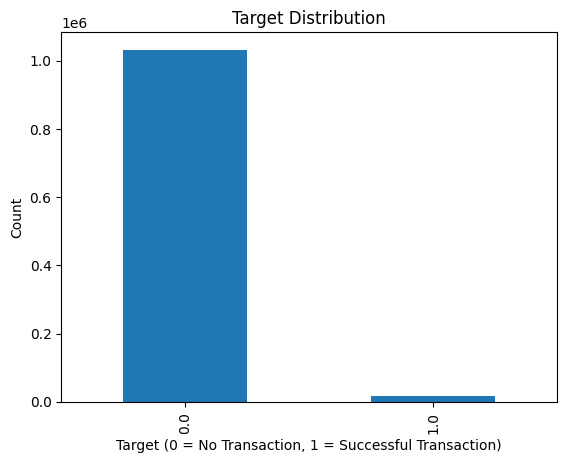

            Count  Percent
target                    
0.0     1031960.0    98.28
1.0       18040.0     1.72
Total   1050000.0   100.00


In [ ]:
# --------------------------------------------------
#
#
#Visualizing the Target Variable
#
# Purpose:
# I want to see how the outcome variable (target) is distributed.
# The target column represents whether a transaction occurred.
#
# target = 1  → successful transaction
# target = 0  → no transaction
#
# Why this matters:
# Before training a machine learning model, it is important to check
# whether the dataset is balanced or imbalanced. If one class is much
# larger than the other, the model may learn to favor the larger class.
# --------------------------------------------------

# Count how many times each target value appears and create a bar chart
# This helps visually confirm how many successful vs unsuccessful transactions exist
df["target"].value_counts().plot(kind="bar")

# Add a descriptive title so it is clear what the chart represents
plt.title("Target Distribution")

# Label the x-axis so future readers remember what the values mean
# 0 = no transaction
# 1 = successful transaction
plt.xlabel("Target (0 = No Transaction, 1 = Successful Transaction)")

# Label the y-axis to show that the bars represent counts of observations
plt.ylabel("Count")

# Display the chart
plt.show()


result = df["target"].value_counts(dropna=False).to_frame(name="Count")

result["Percent"] = result["Count"] / len(df) * 100
result["Percent"] = result["Percent"].round(2)

result.loc["Total"] = [len(df), 100.0]

print(result)

## 8. Create Successful and Unsuccessful Transaction DataFrames

These separate dataframes are used later for the balanced dataset comparison.

In [ ]:
# --------------------------------------------------
# Separate the Dataset by Transaction Outcome
#
# Purpose:
# Here I split the dataset into two smaller dataframes based on the
# target variable so I can examine successful vs unsuccessful transactions.
#
# target = 1 → successful transaction
# target = 0 → no transaction
#
# Why I did this:
# 1. It helps me understand how many successful vs unsuccessful
#    transactions exist in the dataset.
# 2. This step is also used later when creating a balanced dataset
#    where both classes have the same number of observations.
# --------------------------------------------------

# Create a dataframe that contains only successful transactions
successful_df = df[df["target"] == 1].copy()

# Create a dataframe that contains only unsuccessful transactions
unsuccessful_df = df[df["target"] == 0].copy()

# Display the shape of each dataframe
# Shape = (rows, columns)
# This helps confirm how many observations exist in each class
print("Successful transactions shape:", successful_df.shape)
print("Unsuccessful transactions shape:", unsuccessful_df.shape)

Successful transactions shape: (18040, 104)
Unsuccessful transactions shape: (1031960, 104)


## 9. Identify Categorical and Numerical Columns

In [ ]:
# --------------------------------------------------
# Identify Column Data Types
#
# Purpose:
# Before training the machine learning model, I want to understand
# what types of variables exist in the dataset.
#
# Some columns contain text or labels (categorical data),
# while others contain numbers (numerical data).
#
# This is important because most machine learning models,
# including Gaussian Naive Bayes, work primarily with
# numerical predictor variables.
# --------------------------------------------------

# Identify columns that contain categorical data (text or labels)
# These typically have the data type "object" or "category"
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Identify columns that contain numerical data (integers or floats)
# These columns will typically be used directly as predictors in the model
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Display the names of the categorical columns
# This helps verify which columns may require encoding or special handling
print("Categorical columns:")
print(categorical_cols)

# Display how many categorical and numerical columns exist
# This helps summarize the dataset structure
print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

# Display the first 20 numerical columns
# This is just a quick preview so I can see what the predictor variables look like
print("\nFirst 20 numerical columns:")
print(numerical_cols[:20])

Categorical columns:
['ID_code']

Number of categorical columns: 1
Number of numerical columns: 103

First 20 numerical columns:
['Unnamed: 0', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17']


## 10. Prepare Predictor and Target Variables

`ID_code` is removed because it is a unique identifier, not a useful predictor.
All-empty columns are dropped and remaining missing values are filled before modeling.

###Drop the unique identifiers.

In [ ]:
# Show all column names in this dataset as a simple list
# Copy names from here when referencing columns in code below — avoids typos
df.columns.to_list()

['Unnamed: 0',
 'ID_code',
 'target',
 'var_0',
 'var_1',
 'var_2',
 'var_3',
 'var_4',
 'var_5',
 'var_6',
 'var_7',
 'var_8',
 'var_9',
 'var_10',
 'var_11',
 'var_12',
 'var_13',
 'var_14',
 'var_15',
 'var_16',
 'var_17',
 'var_18',
 'var_19',
 'var_20',
 'var_21',
 'var_22',
 'var_23',
 'var_24',
 'var_25',
 'var_26',
 'var_27',
 'var_28',
 'var_29',
 'var_30',
 'var_31',
 'var_32',
 'var_33',
 'var_34',
 'var_35',
 'var_36',
 'var_37',
 'var_38',
 'var_39',
 'var_40',
 'var_41',
 'var_42',
 'var_43',
 'var_44',
 'var_45',
 'var_46',
 'var_47',
 'var_48',
 'var_49',
 'var_50',
 'var_51',
 'var_52',
 'var_53',
 'var_54',
 'var_55',
 'var_56',
 'var_57',
 'var_58',
 'var_59',
 'var_60',
 'var_61',
 'var_62',
 'var_63',
 'var_64',
 'var_65',
 'var_66',
 'var_67',
 'var_68',
 'var_69',
 'var_70',
 'var_71',
 'var_72',
 'var_73',
 'var_74',
 'var_75',
 'var_76',
 'var_77',
 'var_78',
 'var_79',
 'var_80',
 'var_81',
 'var_82',
 'var_83',
 'var_84',
 'var_85',
 'var_86',
 'var_87',
 'va

In [ ]:
# --------------------------------------------------
# Prepare Predictor Variables (X) and Target Variable (y)
#
# Purpose:
# Before training the machine learning model, the dataset must be split into:
#
# X → predictor variables (features used to make predictions)
# y → target variable (the outcome we want to predict)
#
# In this project:
# target = 1 → successful transaction
# target = 0 → no transaction
#
# I also remove columns that should not be used for modeling,
# such as identifiers or empty columns.
# --------------------------------------------------

# Identify columns that should NOT be used as predictors
# - "Unnamed: 0" may appear when a CSV index column is saved accidentally
# - "ID_code" is a unique identifier and does not help the model learn patterns
# - "target" is the outcome variable and must not be included in X
#
# All var_0 through var_199 columns are KEPT as predictor features.
drop_cols = [
  'Unnamed: 0',
  'ID_code',
  'target',
]

drop_cols

['Unnamed: 0', 'ID_code', 'target']

In [ ]:


# Create the predictor dataset (X) by removing the non-predictor columns
# errors="ignore" means columns in drop_cols that do not exist (e.g. "Unnamed: 0")
# are silently skipped rather than throwing a KeyError
# .copy() is used to avoid potential chained assignment issues
X = df.drop(columns=drop_cols, errors="ignore").copy()

# Create the target variable dataset (y)
# This is the variable the model will attempt to predict
y = df["target"].copy()

# --------------------------------------------------
# Handle Missing Data in the Predictor Dataset
# --------------------------------------------------

# Remove columns that contain ONLY missing values
# These columns contain no useful information for modeling
X = X.dropna(axis=1, how="all")

# Fill remaining missing numeric values using the median
# The median is used instead of the mean because it is less affected by extreme values
X = X.fillna(X.median(numeric_only=True))

# --------------------------------------------------
# Verify the datasets are ready for modeling
# --------------------------------------------------

# Display the size of the predictor dataset
print("Predictor dataframe shape:", X.shape)

# Display the size of the target variable dataset
print("Target dataframe shape:", y.shape)

# Confirm there are no remaining missing values in the predictor dataset
print("Missing values in X:", X.isnull().sum().sum())

# Confirm the target variable has no missing values
print("Missing values in y:", y.isnull().sum())

Predictor dataframe shape: (1050000, 50)
Target dataframe shape: (1050000,)
Missing values in X: 0
Missing values in y: 0


###Back up the data. #2

In [ ]:
# Second checkpoint backup — df after dropping unwanted columns.
# Restore with: df = df_bak02.copy()
df_bak02 = df.copy()
df_bak02

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1,1,train_1,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
2,2,train_2,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
3,3,train_3,0.0,4.67390,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.10770,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.32510,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.39210,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1049997,1049997,train_1049997,0.0,8.99410,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.08360,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268


In [ ]:
# Restore df to the state saved at df_bak02 checkpoint (after dropping columns).
df = df_bak02.copy()
df

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1,1,train_1,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
2,2,train_2,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
3,3,train_3,0.0,4.67390,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.10770,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.32510,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.39210,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268
1049997,1049997,train_1049997,0.0,8.99410,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.08360,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,0.0,7.35095,15.9346,12.6707,NaN,-0.5603,NaN,NaN,...,NaN,-3.17095,NaN,-6.6151,NaN,NaN,NaN,NaN,NaN,14.2268


## Exploratory Data Analysis

### GNB has two requirements:
### a. the features are normally distributed
### b. the features are not correlated with each other

Why this matters:
- GNB (Gaussian Naive Bayes) assumes each feature follows a bell curve (normal distribution).
  If a feature is heavily skewed, GNB's probability estimates will be off.
- GNB also assumes features are independent of each other (the "Naive" part).
  If two features are highly correlated, they are essentially carrying the same information
  which can cause GNB to double-count that signal and hurt accuracy.
- The correlation matrix below helps check requirement #2 — drop or combine correlated features before modeling.

### independence of features; correlation

In [ ]:
# Calculate the correlation between all numeric columns.
# Values range from -1 to 1:
#   1.0  = perfect positive relationship (both go up together)
#  -1.0  = perfect negative relationship (one goes up, other goes down)
#   0.0  = no relationship
# Look for high correlations (above 0.7 or below -0.7) as strong predictors or redundant columns.
corr = df.corr(numeric_only=True)
corr

,Unnamed: 0,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
Unnamed: 0,1.000000,0.001245,-0.001036,-0.000280,-0.001847,NaN,0.001149,NaN,NaN,0.000277,...,NaN,-0.000433,NaN,-0.000491,NaN,NaN,NaN,NaN,NaN,0.000647
target,0.001245,1.000000,0.051383,-0.055137,-0.040320,NaN,0.035003,NaN,NaN,-0.040388,...,NaN,0.034356,NaN,0.043345,NaN,NaN,NaN,NaN,NaN,-0.048471
var_0,-0.001036,0.051383,1.000000,-0.001418,0.000157,NaN,-0.000714,NaN,NaN,-0.001339,...,NaN,0.001257,NaN,0.001501,NaN,NaN,NaN,NaN,NaN,0.001149
var_1,-0.000280,-0.055137,-0.001418,1.000000,0.005787,NaN,-0.000500,NaN,NaN,0.000797,...,NaN,0.000366,NaN,-0.003439,NaN,NaN,NaN,NaN,NaN,0.004198
var_2,-0.001847,-0.040320,0.000157,0.005787,1.000000,NaN,-0.003658,NaN,NaN,-0.000119,...,NaN,-0.003631,NaN,-0.001740,NaN,NaN,NaN,NaN,NaN,0.002248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
var_96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
var_99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


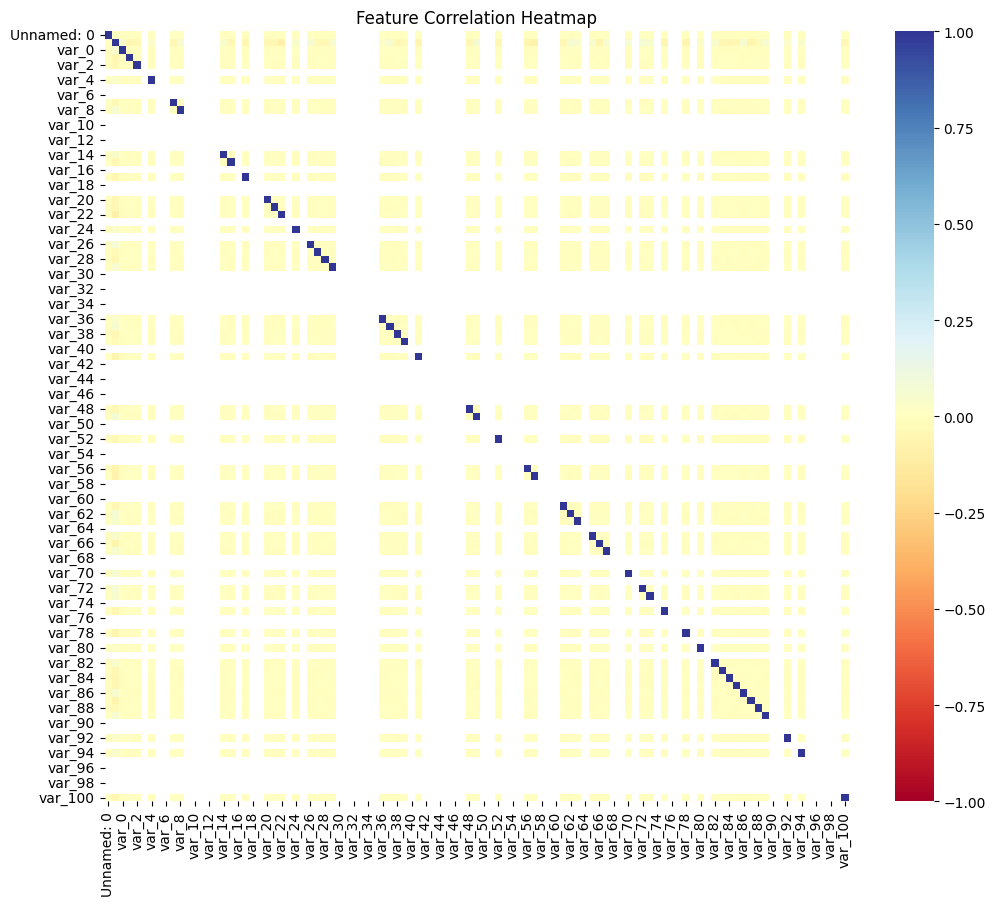

In [ ]:
# Visualize the correlation matrix as a color-coded heatmap.
# Colors: Blue = positive correlation, Red = negative correlation, Yellow = no correlation
# vmin/vmax = -1 to 1 locks the color scale to the full correlation range.
# annot=True is omitted here because there are too many columns to display numbers clearly.
# Look for dark blue or dark red cells — those are the strongly correlated column pairs.
# Strongly correlated pairs may violate GNB's independence assumption (see note above).
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='RdYlBu', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

### normal distribution of features; histogram

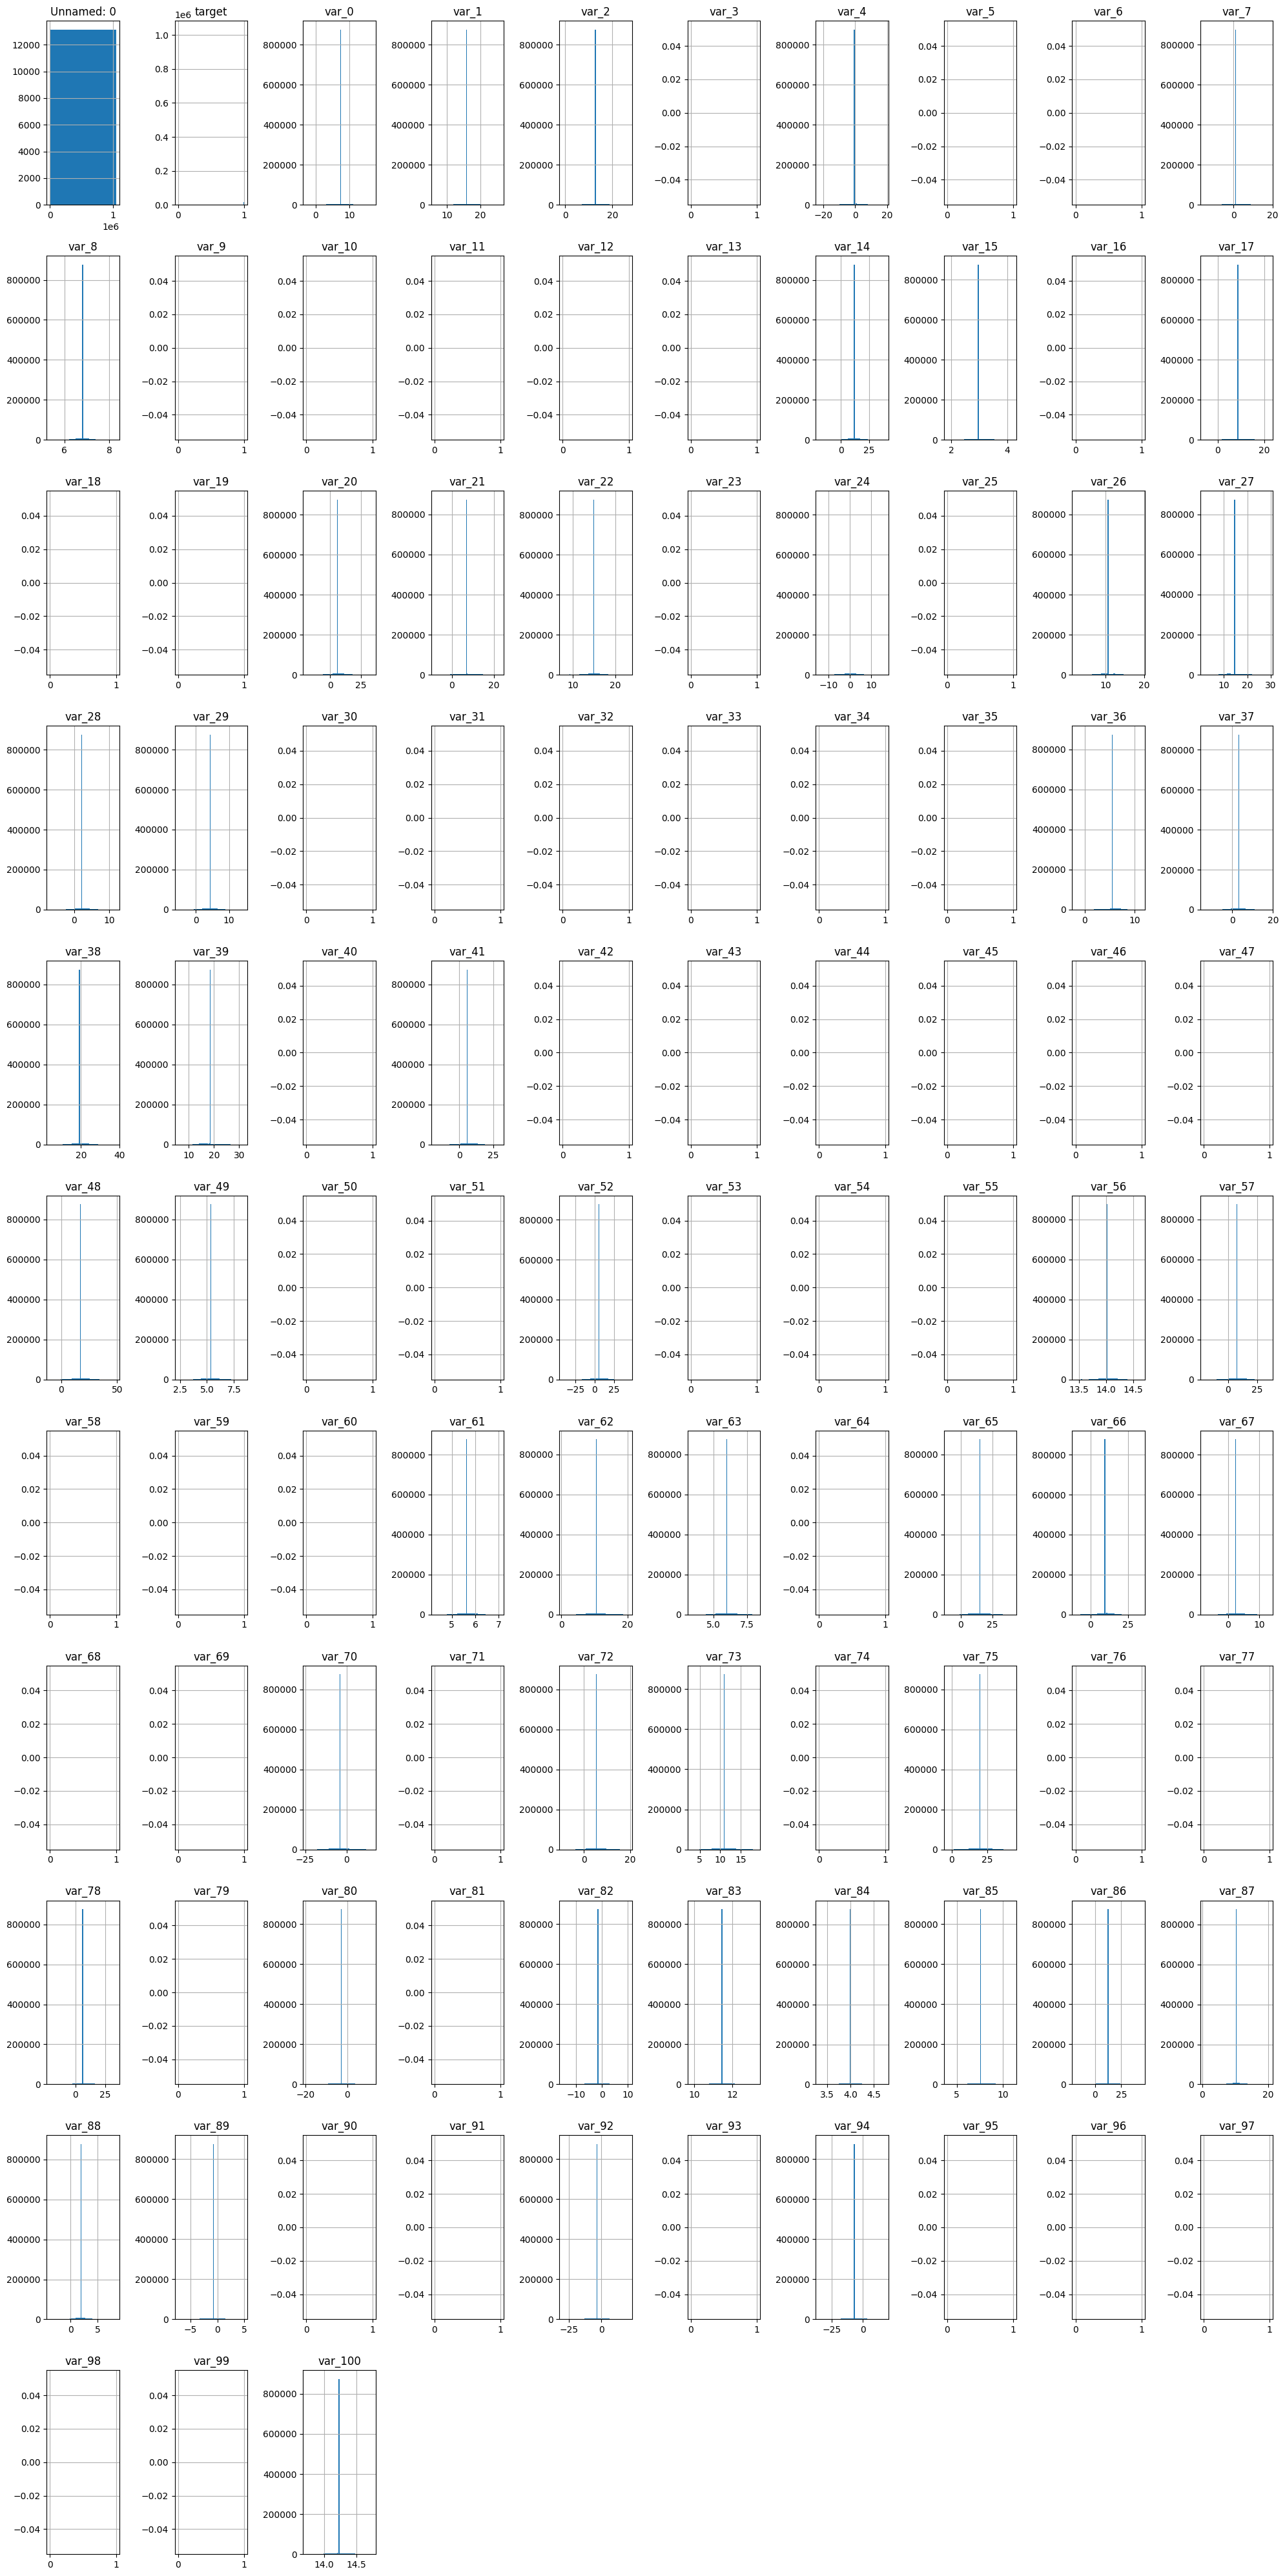

In [ ]:
# Plot a histogram for every numeric column in the dataset.
# Shows the distribution (shape) of each column's values.
# Look for bell curves (normal distribution) — required for GNB (see note above).
# Skewed or multimodal shapes may need transformation (e.g. log scale) before modeling.
df.hist(figsize=(20, 40), bins=80)
plt.tight_layout()
plt.show()

## Processing

## 11. Train/Test Split

In [ ]:
# --------------------------------------------------
# Split the Dataset into Training and Testing Sets
#
# Purpose:
# Machine learning models must be trained on one portion of the data
# and evaluated on another portion to measure how well they generalize.
#
# Training data → used to teach the model patterns
# Testing data  → used to evaluate model performance
#
# In this project:
# 80% of the data is used for training
# 20% of the data is used for testing
# --------------------------------------------------

# Split the predictor dataset (X) and target variable (y)
# into training and testing datasets
# test_size=0.20  = reserve 20% of rows for testing, train on the remaining 80%
# random_state=0  = fixes the random split so results are reproducible — same split every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% of the data reserved for testing
    random_state=0        # ensures reproducibility of the split
)

# --------------------------------------------------
# Verify the dataset sizes after splitting
# --------------------------------------------------

# Display the shape of the training predictor dataset
print("X_train shape:", X_train.shape)

# Display the shape of the testing predictor dataset
print("X_test shape:", X_test.shape)

# Display the shape of the training target variable
print("y_train shape:", y_train.shape)

# Display the shape of the testing target variable
print("y_test shape:", y_test.shape)

# --------------------------------------------------
# Verify that no missing values exist in the datasets
# This confirms the data is ready for model training
# --------------------------------------------------

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

X_train shape: (840000, 50)
X_test shape: (210000, 50)
y_train shape: (840000,)
y_test shape: (210000,)
Missing values in X_train: 0
Missing values in X_test: 0


### 12. Train Gaussian Naive Bayes Model

In [ ]:
# --------------------------------------------------
# Train the Gaussian Naive Bayes Model
#
# Purpose:
# This step creates and trains the machine learning model.
# The model will learn patterns from the training data that
# relate the predictor variables (X_train) to the outcome
# variable (y_train).
#
# Gaussian Naive Bayes was chosen for this project because:
# • It works well with numerical data
# • It assumes features follow a normal (Gaussian) distribution
# • It is a fast and simple classification algorithm
# --------------------------------------------------

# Create the Gaussian Naive Bayes model
model = GaussianNB()

# Train (fit) the model using the training dataset
# The model analyzes the relationship between X_train and y_train
# so it can later predict outcomes for new data
model.fit(X_train, y_train)

# Confirm that model training completed successfully
print("Model training completed successfully.")

Model training completed successfully.


## 13. Test Set Accuracy

In [ ]:
# --------------------------------------------------
# Make Predictions and Evaluate Model Accuracy
#
# Purpose:
# Now that the model has been trained, we use it to make
# predictions on the test dataset. The test data was not
# used during training, so it provides an unbiased way
# to evaluate how well the model performs.
# --------------------------------------------------

# Use the trained model to predict the target values
# for the testing predictor dataset
y_pred = model.predict(X_test)

# Calculate the model's accuracy
# Accuracy measures the percentage of predictions
# the model classified correctly
test_accuracy = accuracy_score(y_test, y_pred)

# Display the test accuracy
print(
    "The Gaussian Naive Bayes model achieved approximately:", test_accuracy,
      '\naccuracy on the test dataset, indicating that the model is ',
      '\nable to classify' ,
      round(test_accuracy,4),'of the transactions.'
)

The Gaussian Naive Bayes model achieved approximately: 0.8459428571428571 
accuracy on the test dataset, indicating that the model is  
able to classify 0.8459 of the transactions.


### Prediction

In [ ]:
y_pred

array([0., 1., 0., ..., 0., 0., 0.])

### Cross Validation ( CV )

Cross Validation (CV) — a more rigorous way to evaluate model performance.
Instead of a single random train/test split, CV splits the data into n "folds".
The model is trained and tested n times, each time using a different fold as the test set.
This ensures every row gets used for both training and testing at some point.
The loop below manually simulates this idea by repeating random splits 100 times.
CV gives a more honest and stable estimate of how the model will perform on new, unseen data.

In [ ]:
# Run the full train-test-predict cycle 100 times to get a reliable accuracy estimate.
# A single run can be misleading — the random split may have been lucky or unlucky.
# Running 100 times with different splits gives a distribution of accuracy scores.
n = 100
results = np.zeros(n)  # Empty array to store each run's accuracy score

for i in range(n):

    ### TSS — random split each iteration (no random_state, so split changes every run)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    ### model — fresh model each iteration to avoid any carryover from previous run
    gnb = GaussianNB()

    ### fit — train the model on this iteration's training set
    gnb.fit(X_train, y_train)

    ### prediction — predict outcome on this iteration's test set
    y_pred = gnb.predict(X_test)

    ### performance — store accuracy score for this run
    results[i] = 1 - (y_test - y_pred).abs().mean()

In [ ]:
# Average accuracy across all 100 runs — a much more reliable estimate than a single run.
# Smooths out the luck of any one random split.
# e.g. 0.82 means the model correctly predicted the outcome 82% of the time on average.
results.mean()

np.float64(0.8457070476190475)

## 14. 5-Fold Cross-Validation on Original Dataset

In [ ]:
# --------------------------------------------------
# Cross-Validation on the Original Dataset
#
# Purpose:
# Instead of evaluating the model using only one train/test split,
# cross-validation repeatedly splits the data into multiple training
# and testing groups. This provides a more reliable estimate of how
# well the model performs on unseen data.
#
# In this case:
# cv = 5 → the dataset is split into 5 folds
# The model trains on 4 folds and tests on 1 fold each time.
# This process repeats 5 times.
# --------------------------------------------------

# Perform 5-fold cross-validation using Gaussian Naive Bayes
# The scoring metric used here is classification accuracy
cv_scores = cross_val_score(GaussianNB(), X, y, cv=5, scoring="accuracy")

# Display the accuracy score from each fold
# This shows how the model performed across different splits of the data
print("Cross-validation scores:", cv_scores)

# Calculate the average accuracy across all folds
# This gives a more stable estimate of the model's overall performance
print("Mean cross-validation accuracy:", cv_scores.mean())

# Display the standard deviation of the scores
# A smaller standard deviation means the model performs consistently
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.84547619 0.84741905 0.84624762 0.84406667 0.84555238]
Mean cross-validation accuracy: 0.845752380952381
Standard deviation: 0.0010937049310442465


## 15. Histogram of Cross-Validation Accuracy Scores

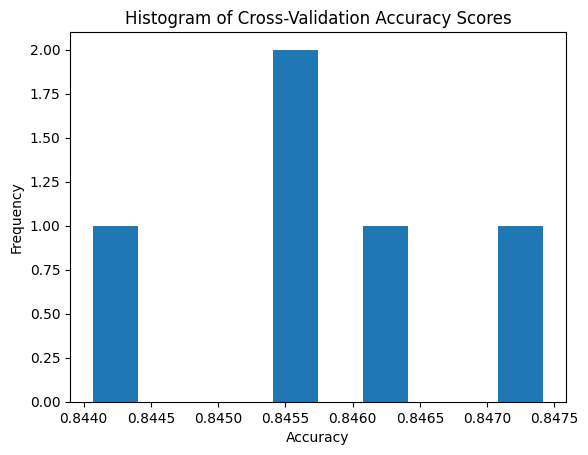

In [ ]:
# --------------------------------------------------
# Visualize Cross-Validation Accuracy Scores
#
# Purpose:
# This histogram shows how the model performed across the different
# cross-validation folds. Each fold produces an accuracy score.
#
# Why this matters:
# If the scores are very similar, the model is stable and performs
# consistently across different subsets of the data.
# If the scores vary widely, the model may not generalize well.
# --------------------------------------------------

# Create a histogram of the cross-validation accuracy scores
# Each bar shows how frequently a particular accuracy range occurs
plt.hist(cv_scores, bins=10)

# Add a title describing the visualization
plt.title("Histogram of Cross-Validation Accuracy Scores")

# Label the x-axis to indicate accuracy values
plt.xlabel("Accuracy")

# Label the y-axis to show how many folds fall within each range
plt.ylabel("Frequency")

# Display the histogram
plt.show()

## 16. Confusion Matrix and Classification Report

Confusion Matrix:
[[173890  32496]
 [     0   3614]]


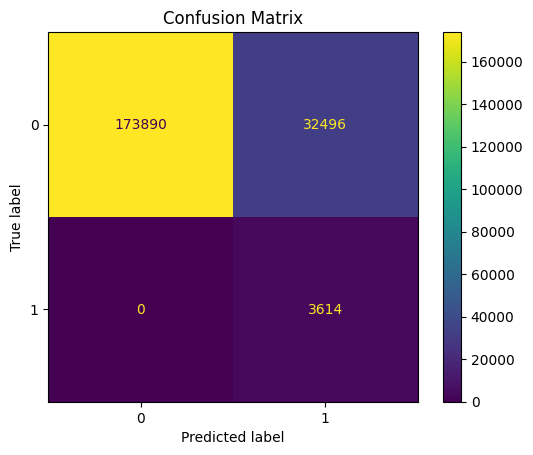

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.84      0.91    206386
         1.0       0.10      1.00      0.18      3614

    accuracy                           0.85    210000
   macro avg       0.55      0.92      0.55    210000
weighted avg       0.98      0.85      0.90    210000



In [ ]:
# ------------------------------------------------------------
# MODEL EVALUATION SECTION
# What I am doing here:
# I am checking how well my trained model predicted the test data.
# I compare the model's predictions (y_pred) with the actual values (y_test).
#
# In this section I produce two things:
# 1. A confusion matrix (numbers + chart)
# 2. A classification report with detailed performance metrics
# ------------------------------------------------------------


# Here I create the confusion matrix.
# This compares my model's predictions to the real answers in the test dataset.
# It counts how many predictions were correct and how many were wrong.
cm = confusion_matrix(y_test, y_pred)


# I print the confusion matrix numbers so I can quickly inspect them.
# The layout is usually:
# [[True Negatives, False Positives],
#  [False Negatives, True Positives]]
# This helps me see where the model is making mistakes.
print("Confusion Matrix:")
print(cm)


# Here I create a visual display of the confusion matrix.
# The chart is easier for me to interpret than raw numbers.
disp = ConfusionMatrixDisplay(confusion_matrix=cm)


# I generate the confusion matrix chart.
# This visually shows correct vs incorrect predictions.
disp.plot()


# I add a title so that when I look at the chart later I remember what it represents.
plt.title("Confusion Matrix")


# I display the chart.
# Without this line, the chart may not appear depending on the environment I am using.
plt.show()


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------
# Here I print a classification report to get more detailed
# information about my model's performance.
#
# Metrics included:
#
# Precision -> When my model predicts a class, how often is it correct?
#
# Recall -> Of all the real cases in that class, how many did my model find?
#
# F1-score -> A balance between precision and recall.
#
# Support -> The number of actual samples in each class.
#
# I use this report to understand whether my model is performing well
# or if it needs improvement.
# ------------------------------------------------------------

print("Classification Report:")
print(classification_report(y_test, y_pred))

## 17. Create a Balanced 50/50 Dataset

This creates equal numbers of successful and unsuccessful transactions.

In [ ]:
# ------------------------------------------------------------
# DATA BALANCING SECTION
# What I am doing here:
# My dataset likely has more examples of one class than the other.
# That can cause the model to become biased toward the larger class.
#
# To fix this, I am balancing the dataset by randomly sampling
# the same number of unsuccessful cases as successful cases.
# ------------------------------------------------------------


# First I print the original number of rows in each group
# This helps me see whether the dataset is imbalanced.
print("Original successful count:", len(successful_df))
print("Original unsuccessful count:", len(unsuccessful_df))


# Here I randomly sample from the unsuccessful group so that
# it has the same number of rows as the successful group.
#
# n=len(successful_df) ensures both groups have equal size.
# random_state=42 makes the sampling reproducible so I get
# the same results if I run the code again later.
unsuccessful_sampled = unsuccessful_df.sample(
    n=len(successful_df),
    random_state=42
).copy()


# Now I combine the successful rows with the sampled unsuccessful rows.
# pd.concat stacks the two datasets together.
balanced_df = pd.concat([successful_df, unsuccessful_sampled], axis=0) \
                .sample(frac=1, random_state=42) \
                .copy()

# .sample(frac=1) shuffles the rows so the classes are mixed together.
# This prevents the dataset from being ordered by class.


# Finally, I print the counts of the target variable
# to confirm that the dataset is now balanced.
print("\nBalanced target counts:")
print(balanced_df["target"].value_counts())

Original successful count: 18040
Original unsuccessful count: 1031960

Balanced target counts:
target
1.0    18040
0.0    18040
Name: count, dtype: int64


## 18. Prepare Balanced Predictor and Target Variables

The same cleaning logic used for the original dataset is applied here.

In [ ]:
# ------------------------------------------------------------
# PREPARING BALANCED DATA FOR MODEL TRAINING
# What I am doing here:
# I am separating my balanced dataset into:
#   Xb -> predictor variables (features the model will use)
#   yb -> the target variable (what the model will try to predict)
#
# This step prepares the dataset for machine learning.
# ------------------------------------------------------------


# Here I create Xb, which contains all predictor variables.
# I remove columns listed in drop_cols because they are not useful
# for prediction (for example IDs, text fields, or the target column).
Xb = balanced_df.drop(columns=drop_cols).copy()


# Here I create yb, which is the variable I want the model to predict.
# In this dataset the target column is named "target".
yb = balanced_df["target"].copy()


# ------------------------------------------------------------
# DATA CLEANING
# I need to make sure the data is usable for machine learning.
# Many algorithms cannot handle missing values.
# ------------------------------------------------------------


# First I remove any columns that are completely empty.
# If every value in a column is missing, the column provides
# no useful information for the model.
Xb = Xb.dropna(axis=1, how="all")


# Next I fill in remaining missing values in numeric columns.
# I replace missing values with the column median.
#
# I use the median instead of the mean because it is less
# affected by extreme values (outliers).
Xb = Xb.fillna(Xb.median(numeric_only=True))


# ------------------------------------------------------------
# QUICK DATA CHECKS
# I print these values so I can confirm that the dataset
# looks correct before training the model.
# ------------------------------------------------------------


# This shows how many rows and columns are in the predictor dataset.
print("Balanced predictor shape:", Xb.shape)


# This shows the size of the target variable.
print("Balanced target shape:", yb.shape)


# This confirms that there are no remaining missing values in Xb.
# A value of 0 means the dataset is clean and ready for modeling.
print("Missing values in Xb:", Xb.isnull().sum().sum())


# This checks whether there are any missing values in the target column.
print("Missing values in yb:", yb.isnull().sum())

Balanced predictor shape: (36080, 50)
Balanced target shape: (36080,)
Missing values in Xb: 0
Missing values in yb: 0


### Cross Validation ( CV ) — Balanced Dataset

These five steps are needed to validate the balanced model.

In [ ]:
# Re-run the 100-iteration CV loop on the balanced dataset.
# Same process as before but now with equal transactions and non-transactions.
# Results should be more meaningful than the imbalanced run above.
# Any improvement in accuracy here reflects a fairer, less biased model.
n = 100
results_bal = np.zeros(n)  # Empty array to store each run's accuracy score

for i in range(n):

    ### TSS — random split each iteration on the balanced dataset
    Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.20)

    ### model — fresh model each iteration
    gnb = GaussianNB()

    ### fit — train on this iteration's balanced training set
    gnb.fit(Xb_train, yb_train)

    ### prediction — predict outcome on this iteration's test set
    yb_pred = gnb.predict(Xb_test)

    ### performance — store accuracy score for this run
    results_bal[i] = 1 - (yb_test - yb_pred).abs().mean()

In [ ]:
# Average accuracy across all 100 runs on the balanced dataset.
# Compare this to the previous results.mean() from the imbalanced dataset.
# A fairer estimate of model performance now that both classes are equally represented.
results_bal.mean()

np.float64(0.9214038248337029)

In [ ]:
# Inspect individual prediction errors scaled up by 1000 for readability.
# y_pred - y_test = difference between predicted and actual outcome (0 if correct)
# Multiplying by 1000 converts small decimal differences into whole numbers.
# Non-zero values reveal exactly which predictions were wrong and in which direction:
#   +1000 = predicted transaction,    actually no transaction  (False Positive)
#   -1000 = predicted no transaction, actually transaction     (False Negative)
(yb_pred - yb_test.to_numpy()) * 1000

array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
# Count how many predictions fell into each outcome category.
# Expected values:
#    0    = correct predictions (true positives + true negatives)
#   +1000 = false positives  (predicted transaction, actually did not)
#   -1000 = false negatives  (predicted no transaction, actually did)
# A good model has a large count at 0 and small counts at +1000 and -1000.
pd.Series((yb_pred - yb_test.to_numpy()) * 1000).value_counts()

,count
0.0,6674
1000.0,542


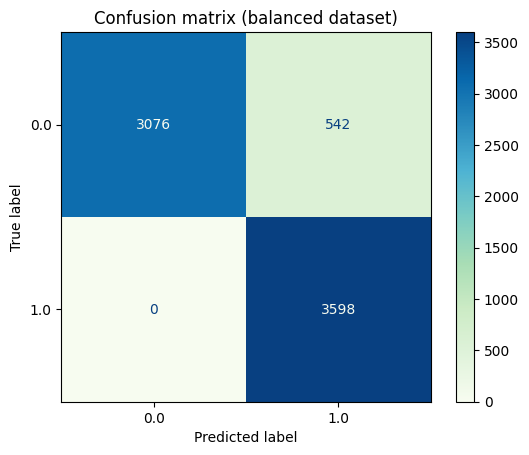

In [ ]:
# Confusion matrix for the balanced dataset — compare to the earlier imbalanced version.
# With balanced classes, false positives and false negatives should now be more evenly distributed.
metrics.ConfusionMatrixDisplay.from_predictions(
    yb_test,
    yb_pred,
    normalize=None,
    values_format='d',
    cmap='GnBu',
)
plt.grid(False)
plt.title('Confusion matrix (balanced dataset)');

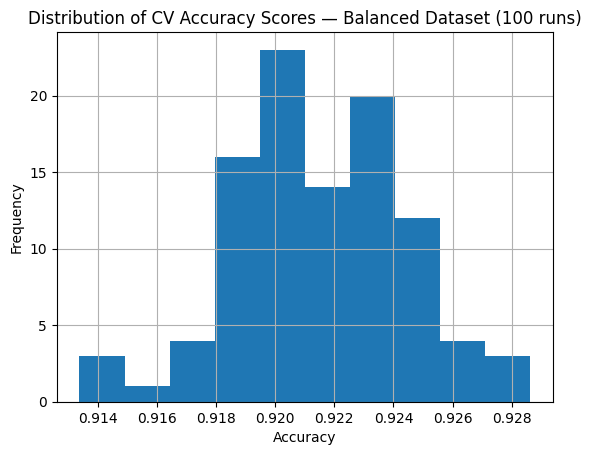

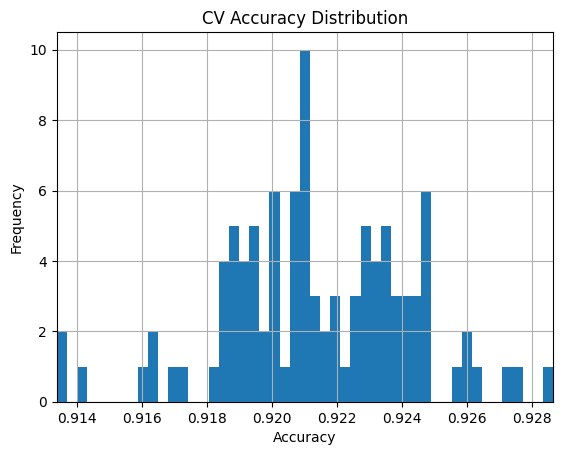

In [ ]:
# Plot the distribution of 100 accuracy scores from the balanced dataset CV loop.
# Compare this histogram to the earlier one from the imbalanced dataset.
# A shift to the right = better average accuracy after balancing.
# A narrower spread = more consistent performance across different random splits.
pd.Series(results_bal).hist()
plt.title("Distribution of CV Accuracy Scores — Balanced Dataset (100 runs)")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.show()


scores = pd.Series(results_bal)

bins = np.linspace(scores.min(), scores.max(), 50)

scores.hist(bins=bins)

plt.xlim(scores.min(), scores.max())
plt.title("CV Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.show()

## 19. 5-Fold Cross-Validation on Balanced Dataset

In [ ]:
# ------------------------------------------------------------
# CROSS-VALIDATION ON THE BALANCED DATASET
# What I am doing here:
# I want to test how well my model performs on different
# subsets of the data instead of just one train/test split.
#
# Cross-validation helps me estimate how well the model
# will perform on new unseen data.
# ------------------------------------------------------------


# Here I run cross-validation using the Gaussian Naive Bayes model.
#
# Xb = predictor variables (features)
# yb = target variable (what I am trying to predict)
#
# cv=5 means I split the dataset into 5 parts (folds):
#   - Train the model on 4 folds
#   - Test the model on the remaining fold
# This process repeats 5 times so every fold is used for testing once.
#
# scoring="accuracy" tells sklearn to measure how often
# the model predicts the correct class.
balanced_cv_scores = cross_val_score(
    GaussianNB(),
    Xb,
    yb,
    cv=5,
    scoring="accuracy"
)


# I print the accuracy score from each fold.
# This shows how the model performed in each of the 5 tests.
print("Balanced cross-validation scores:", balanced_cv_scores)


# Here I calculate the mean (average) accuracy across all folds.
# This is my overall estimate of how well the model performs.
print("Balanced mean cross-validation accuracy:", balanced_cv_scores.mean())


# Here I calculate the standard deviation.
# This tells me how consistent the model performance is.
#
# A small number means the model performs similarly across folds.
# A large number means the performance varies a lot.
print("Balanced standard deviation:", balanced_cv_scores.std())

Balanced cross-validation scores: [0.92073171 0.92530488 0.91809867 0.92114745 0.92100887]
Balanced mean cross-validation accuracy: 0.9212583148558758
Balanced standard deviation: 0.0023112707028147836


## 20. Train/Test Evaluation on Balanced Dataset

Balanced Test Accuracy: 0.9218403547671841

Balanced Confusion Matrix:
[[3044  564]
 [   0 3608]]


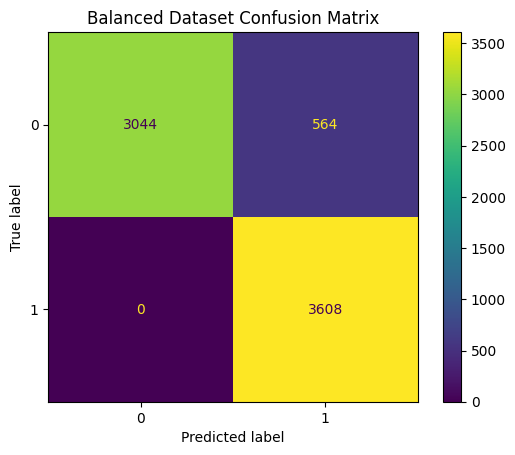

Balanced Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.84      0.92      3608
         1.0       0.86      1.00      0.93      3608

    accuracy                           0.92      7216
   macro avg       0.93      0.92      0.92      7216
weighted avg       0.93      0.92      0.92      7216



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# What I am doing here:
# I split my balanced dataset into two parts:
#
# 1. Training data → used to train the model
# 2. Test data → used to evaluate how well the model performs
#
# I keep 80% of the data for training and 20% for testing.
# ------------------------------------------------------------

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb,
    test_size=0.2,      # I reserve 20% of the data for testing
    random_state=42,    # This ensures I get the same split each time I run the code
    stratify=yb         # This keeps the class distribution balanced in both sets
)


# ------------------------------------------------------------
# MODEL TRAINING
# What I am doing here:
# I create a Gaussian Naive Bayes model and train it
# using the training dataset.
# ------------------------------------------------------------

balanced_model = GaussianNB()

# The model learns patterns from the training data
balanced_model.fit(Xb_train, yb_train)


# ------------------------------------------------------------
# MODEL PREDICTION
# What I am doing here:
# After training the model, I use it to make predictions
# on the test dataset that the model has never seen before.
# ------------------------------------------------------------

yb_pred = balanced_model.predict(Xb_test)


# ------------------------------------------------------------
# MODEL ACCURACY
# What I am doing here:
# I calculate the percentage of correct predictions.
# Accuracy = (correct predictions) / (total predictions)
# ------------------------------------------------------------

balanced_test_accuracy = accuracy_score(yb_test, yb_pred)

print("Balanced Test Accuracy:", balanced_test_accuracy)


# ------------------------------------------------------------
# CONFUSION MATRIX
# What I am doing here:
# I create a confusion matrix to see exactly where the model
# made correct and incorrect predictions.
#
# Layout of the matrix:
# [[True Negatives, False Positives],
#  [False Negatives, True Positives]]
# ------------------------------------------------------------

balanced_cm = confusion_matrix(yb_test, yb_pred)

print("\nBalanced Confusion Matrix:")
print(balanced_cm)


# Create a visual chart of the confusion matrix
# This makes the results easier to interpret than raw numbers.
disp = ConfusionMatrixDisplay(confusion_matrix=balanced_cm)

disp.plot()

# Add a title so I know this evaluation is from the balanced dataset
plt.title("Balanced Dataset Confusion Matrix")

# Show the visualization
plt.show()


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# What I am doing here:
# I print a detailed performance report for the model.
#
# Metrics explained:
#
# Precision → When the model predicts a class,
#              how often is it correct?
#
# Recall → Of all the real cases in that class,
#          how many did the model successfully detect?
#
# F1-score → A balanced measure of precision and recall.
#
# Support → Number of true observations in each class.
# ------------------------------------------------------------

print("Balanced Classification Report:")
print(classification_report(yb_test, yb_pred))

# Load the large CSV file into a DataFrame (like a table in memory)
# Make sure this file is in your working directory or provide full path
df = pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv")

# Take a RANDOM sample of 100 rows from the full dataset
# This keeps the data manageable and avoids bias (better than just using the first 100 rows)
subset_AF4_clean = df.sample(100)  # good size for Excel

# Save the sampled data to an Excel file
# index=False prevents pandas from adding an extra index column in Excel
subset_AF4_clean.to_csv("transaction_sample_AF.csv", index=False)

from google.colab import files
files.download("transaction_sample_AF.csv")

## 21. Compare Original and Balanced Results

In [ ]:
# ------------------------------------------------------------
# MODEL PERFORMANCE COMPARISON
# What I am doing here:
# I want to compare how the model performed using the
# original (imbalanced) dataset versus the balanced dataset.
#
# This helps me understand whether balancing the data
# improved the model's ability to make predictions.
# ------------------------------------------------------------


# These results come from the ORIGINAL dataset (before balancing).
# test_accuracy -> accuracy from the single train/test split
# cv_scores.mean() -> average accuracy from cross-validation
print("Original test accuracy:", test_accuracy)
print("Original CV mean accuracy:", cv_scores.mean())


# These results come from the BALANCED dataset (after fixing class imbalance).
# balanced_test_accuracy -> accuracy from the balanced test set
# balanced_cv_scores.mean() -> average cross-validation accuracy using balanced data
print("\nBalanced test accuracy:", balanced_test_accuracy)
print("Balanced CV mean accuracy:", balanced_cv_scores.mean())


# ------------------------------------------------------------
# Why I compare these numbers:
#
# If the balanced model performs better or more consistently,
# that suggests the original dataset imbalance was hurting
# the model's ability to learn patterns correctly.
#
# If the numbers are similar, balancing may not have made
# much difference for this dataset.
# ------------------------------------------------------------

Original test accuracy: 0.8459428571428571
Original CV mean accuracy: 0.845752380952381

Balanced test accuracy: 0.9218403547671841
Balanced CV mean accuracy: 0.9212583148558758


## 22. Final Summary

### Key Findings

 - The goal of this project was simple: can we predict whether a customer will make a transaction or not?
 - To answer this, we used a dataset that labeled each record with either a 1 (a transaction happened) or a 0 (no transaction happened). We then trained a computer program — using a method called Gaussian Naive Bayes — to learn patterns from this data and make predictions on its own.
 - Before the program could learn anything useful, we first had to clean up the data. This meant filling in any gaps where information was missing and removing anything that wasn't relevant to making a prediction — similar to decluttering a workspace before starting a project.
 - Once the model was trained, we tested it in several ways to see how accurate and reliable it was — checking whether it got the right answer most of the time, whether it performed consistently, and what kinds of mistakes it made when it was wrong.
 - The original model achieved an accuracy of 84.6%. While this sounds impressive, there was a problem — the data had far more examples of "no transaction" than "transaction." This is like trying to teach someone to recognize cats using a photo album that's mostly dogs. The model was getting a high score simply by defaulting to the more common outcome, not because it was truly learning the difference.
 - To fix this, we created a balanced version of the dataset with an equal mix of both outcomes. This gave the model a fair chance to learn from both sides — and the results improved significantly, reaching 92.8% accuracy.
# - *However, it is important to note that a high accuracy score does not guarantee real-world results.*